## Common Imports

In [1]:
## Common Imports
from src.barbara_functions_for_notebooks_1_2_3_4_5 import filter_ra_only, export_to_csv
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from src.barbara_functions_for_notebooks_1_2_3_4_5 import load_autoimmune_data, get_duplicate_patient_ids, \
    get_duplicate_values, check_duplicate_protein_ids, transpose_autoimmune_data, split_bl_m6, harmonisation_validator
from src.barbara_functions_for_notebooks_1_2_3_4_5 import plot_global_distribution, compute_global_skewness, \
    compute_global_range, compute_quantiles, log_transform_assessment, plot_protein_distributions, protein_skewness, \
    protein_outlier_summary, log_normalise, standardise_data

## Define directory and file paths

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_DIR = PROJECT_ROOT / "datasets"
INITIAL_AUTOIMMUNE_FILE = "1_Initial_Autoimmune.xlsx"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY = "2_Initial_Autoimmune_RA_Only.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED = "3_Initial_Autoimmune_RA_Only_Transposed.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL = "4_Initial_Autoimmune_RA_Only_Transposed_BL.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_M6 = "5_Initial_Autoimmune_RA_Only_Transposed_M6.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL_LOG = "6_Initial_Autoimmune_RA_Only_Transposed_BL_Log.csv"


print(Path.cwd())
print(Path(DATA_DIR))
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED)

C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\notebooks\preprocessing
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\1_Initial_Autoimmune.xlsx
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\2_Initial_Autoimmune_RA_Only.csv
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\3_Initial_Autoimmune_RA_Only_Transposed.csv


## Load the Baseline (BL) dataset that has already been log transformed to standardise the data by transforming to z-scores

In [3]:
bl_dataset_log = load_autoimmune_data(DATA_DIR,INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL_LOG)
bl_dataset_log.head()

Loaded: C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\6_Initial_Autoimmune_RA_Only_Transposed_BL_Log.csv
Shape: (265, 163)
Index name: Patient_Timepoint


,104740305_XRCC6,104741891_SNRPD1,104742995_ACTB,104743232_PTBP1,104743420_FEN1,104743520_EIF4H,104745245_TNC,104745249_IGF1,104745436_FN1,104745443_IGFBP2,...,APOH_1113180421_APOH,HN1L_1043144040_HN1L,HNRNPA1_1066859223_HNRNPA1,HNRNPA2B1_1066866713_HNRNPA2B1,KDM6B_0172047444_KDM6B,KDM6B_1113180399_KDM6B,MVP_1066863544_MVP,NONO_0105507292_NONO,TMPO_1066866329_TMPO,ZNF574_1066529052_ZNF574
Patient_Timepoint,,,,,,,,,,,,,,,,,,,,,
TAC1241_BL,4.766438,6.028279,5.817111,5.541264,4.564348,6.393591,5.671604,6.111467,5.527443,6.569481,...,5.129899,3.850148,5.579730,5.147494,4.644391,4.406719,7.632886,5.153292,4.908972,4.644391
TAC1147_BL,5.206750,4.343805,5.470168,4.639572,3.988984,4.875197,4.919981,4.521789,5.123964,5.808142,...,5.497168,3.637586,4.644391,4.718499,3.806662,4.135167,9.153770,5.624018,3.663562,4.477337
TAC1094_BL,5.600272,6.052089,5.535364,5.738184,5.120983,6.554645,5.652489,6.287859,5.638355,6.751101,...,5.568345,4.584967,5.894403,5.552960,4.770685,4.997212,7.663408,5.262690,5.147494,4.948760
TAC1272_BL,5.075174,5.273000,6.684612,5.056246,4.043051,5.847883,5.605802,5.493061,6.040255,6.485398,...,4.672829,4.034241,7.241366,5.295814,4.579852,4.043051,8.809340,6.161207,4.488636,4.927254
TAC1096_BL,5.347108,4.418841,5.505332,4.564348,3.784190,5.036953,4.394449,4.787492,4.934474,5.167639,...,4.158883,4.430817,4.388257,4.204693,5.680173,6.295266,8.442470,5.493061,3.737670,5.527443


## Standardise the log-transformed data by transforming to z-scores to have mean of 0 and standard deviation of 1

In [4]:
bl_dataset_log_standardised = standardise_data(bl_dataset_log)
bl_dataset_log_standardised.head()

Standardisation complete
Shape: (265, 163)


,104740305_XRCC6,104741891_SNRPD1,104742995_ACTB,104743232_PTBP1,104743420_FEN1,104743520_EIF4H,104745245_TNC,104745249_IGF1,104745436_FN1,104745443_IGFBP2,...,APOH_1113180421_APOH,HN1L_1043144040_HN1L,HNRNPA1_1066859223_HNRNPA1,HNRNPA2B1_1066866713_HNRNPA2B1,KDM6B_0172047444_KDM6B,KDM6B_1113180399_KDM6B,MVP_1066863544_MVP,NONO_0105507292_NONO,TMPO_1066866329_TMPO,ZNF574_1066529052_ZNF574
Patient_Timepoint,,,,,,,,,,,,,,,,,,,,,
TAC1241_BL,-0.009715,1.097897,0.046379,0.331484,0.181851,0.619008,0.463810,1.020058,0.347072,0.477471,...,0.557537,-0.417373,0.365968,-0.180048,-0.449253,0.033165,-0.210692,-0.397600,0.386711,-0.533976
TAC1147_BL,0.496561,-1.062721,-0.301921,-0.639796,-0.526840,-1.078277,-0.634152,-1.081023,-0.399196,-0.390587,...,1.095931,-0.639276,-0.777052,-0.614710,-1.138089,-0.349940,1.199783,0.041470,-1.177078,-0.653822
TAC1094_BL,0.949037,1.128439,-0.236470,0.543602,0.867474,0.799037,0.435888,1.253195,0.552212,0.684550,...,1.200270,0.349743,0.750511,0.230773,-0.345405,0.866227,-0.182385,-0.295558,0.686211,-0.315620
TAC1272_BL,0.345273,0.129126,0.917269,-0.190965,-0.460244,0.009007,0.367688,0.202710,1.295559,0.381602,...,-0.112498,-0.225189,2.396552,-0.029769,-0.502321,-0.479895,0.880358,0.542535,-0.141079,-0.331048
TAC1096_BL,0.657945,-0.966476,-0.266620,-0.720824,-0.779091,-0.897464,-1.401843,-0.729843,-0.749673,-1.120872,...,-0.865910,0.188817,-1.090058,-1.135304,0.402437,2.697510,0.540120,-0.080679,-1.084024,0.099532


## Verify successful standardisation

In [5]:
#Expected output mean ≈ 0 std ≈ 1
check = pd.DataFrame({"mean": bl_dataset_log_standardised.mean(), "std": bl_dataset_log_standardised.std()})

print(check.head(10))

                          mean       std
104740305_XRCC6  -7.775751e-16  1.001892
104741891_SNRPD1 -2.279099e-16  1.001892
104742995_ACTB   -4.290069e-16  1.001892
104743232_PTBP1   6.569169e-16  1.001892
104743420_FEN1    4.021940e-16  1.001892
104743520_EIF4H  -3.988424e-16  1.001892
104745245_TNC    -1.635589e-15  1.001892
104745249_IGF1    2.145035e-16  1.001892
104745436_FN1    -8.244977e-16  1.001892
104745443_IGFBP2 -3.485681e-16  1.001892


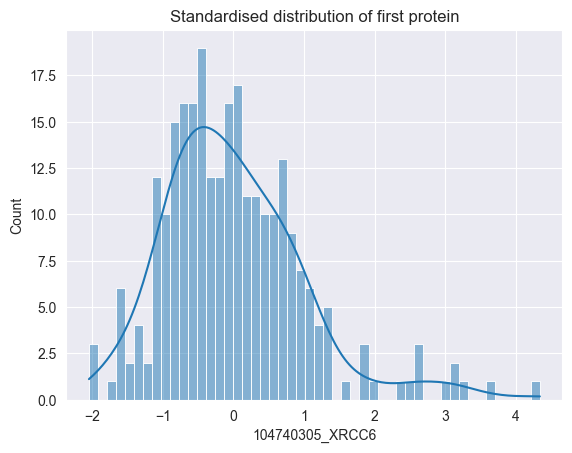

In [6]:
sns.histplot(bl_dataset_log_standardised.iloc[:, 0], bins=50, kde=True)
plt.title("Standardised distribution of first protein")
plt.show()

In [7]:
bl_dataset_log_standardised.describe().T[["mean", "std"]].head()

,mean,std
104740305_XRCC6,-7.775751e-16,1.001892
104741891_SNRPD1,-2.279099e-16,1.001892
104742995_ACTB,-4.290069e-16,1.001892
104743232_PTBP1,6.569169e-16,1.001892
104743420_FEN1,4.021940e-16,1.001892


## Export the standardised dataset as .csv for use in the post-standardisation visualisations

In [8]:
export_to_csv(bl_dataset_log_standardised, f"{DATA_DIR}/7_Initial_Autoimmune_RA_Only_Transposed_BL_Log_Standardised.csv")

File saved to: C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets/7_Initial_Autoimmune_RA_Only_Transposed_BL_Log_Standardised.csv
